# Detection - Stage 1: candidate generation (SG 2nd-derivative threshold)

Cascade layer 1: a cheap, high-recall spike detector that proposes candidate `(channel, time)` peaks.
It is **not** a classifier - it thresholds a signal-processing statistic. Layer 2 (the existing FDA
classifier, retrained on candidates) discriminates IED vs non-IED later.

**Why this is the gating experiment.** A spike missed here is never seen by layer 2, so **layer-1 recall
caps the whole system**. This notebook answers the only question that matters before building the rest:
does an SG 2nd-derivative threshold recover ~all annotated IEDs at a candidate rate layer 2 can handle?

**Method.** Per channel: Savitzky-Golay smooth, take the analytic **2nd derivative = curvature = sharpness**,
normalise by per-channel MAD (channel-adaptive threshold), and pick peaks (`find_peaks`, `distance`=NMS so
one spike's up-stroke/peak/down-stroke collapse to one candidate). Pool candidates across the 19 common
10-20 channels. Recorded reference (v1; bipolar/average deferred).

**Metrics** (verified single-IED ground truth makes these honest):
- **IED recall** = fraction of the 54 epileptic markers with a candidate within +/-100 ms *on any channel*.
  Missing a *mimic* (negative recording's transient) is harmless, so recall is measured over IEDs only.
- **candidate rate** /min and **false-positive rate** /min (every candidate not within tolerance of an IED
  marker is a confirmed FP). This is the raw operating curve of the front end, before layer 2.

Tune the threshold for recall, not rate. This is single-channel-pooled; **spatial grouping (deferred) will
cut the FP rate** by collapsing one physical IED's per-channel candidates into one event.

In [9]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
from scipy.signal import savgol_filter, find_peaks
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import CH19, SF, load_dataset   # preprocessing lives in src/
Path('../figures').mkdir(exist_ok=True)

SG_WIN, SG_POLY = 21, 3      # 42 ms window, cubic; near spike width, preserves peaks
NMS  = int(0.15 * SF)        # 150 ms within-event merge (morphology-scale, not window-scale)
TOL  = int(0.10 * SF)        # +-100 ms hit tolerance
THRESHOLDS = [4, 5, 6, 8, 12, 16, 20, 30]

In [10]:
man  = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
recs = load_dataset(man, Path('..') / 'Kural_Dataset' / 'Recordings')   # full recordings, 19 ch
# Feasibility notebook: detector characterised on all 100 (recall is not a fitted quantity).
# The train/test split + train-only threshold selection belong to the downstream eval, not here.
TOT_MIN = sum(r['dur'] for r in recs) / 60
N_IED   = sum(r['epi'] for r in recs)
print(f"{len(recs)} recordings, {len(CH19)} channels, {TOT_MIN:.1f} min total, {N_IED} IEDs")

100 recordings, 19 channels, 21.1 min total, 54 IEDs


In [11]:
def sharpness(x):
    """Per-channel SG 2nd-derivative magnitude, MAD-normalised (channel-adaptive units)."""
    d2 = savgol_filter(x, SG_WIN, SG_POLY, deriv=2, delta=1 / SF)
    s  = np.abs(d2)
    return s / (np.median(np.abs(s - np.median(s))) + 1e-12)

# precompute the statistic once per channel; threshold sweep is then just find_peaks
STAT = [np.stack([sharpness(r['X'][ci]) for ci in range(len(CH19))]) for r in recs]

def candidates(stat, thresh):
    out = []
    for ci in range(stat.shape[0]):
        pk, _ = find_peaks(stat[ci], height=thresh, distance=NMS)
        out += [(ci, int(p)) for p in pk]
    return out

In [12]:
rows = []
for th in THRESHOLDS:
    hits = ncand = ntp = 0
    for r, stat in zip(recs, STAT):
        cs = candidates(stat, th); ncand += len(cs)
        if r['epi']:
            tp = [c for c in cs if abs(c[1] - r['mk']) <= TOL]
            ntp += len(tp)
            hits += bool(tp)
    rows.append(dict(threshold=th, ied_recall=hits / N_IED,
                     cand_per_min=ncand / TOT_MIN, fp_per_min=(ncand - ntp) / TOT_MIN))
op = pd.DataFrame(rows)
print(op.to_string(index=False,
      formatters={'ied_recall': '{:.2f}'.format, 'cand_per_min': '{:.0f}'.format, 'fp_per_min': '{:.0f}'.format}))

 threshold ied_recall cand_per_min fp_per_min
         4       1.00         3995       3948
         5       1.00         2777       2734
         6       1.00         1703       1664
         8       0.98          579        550
        12       0.85          115         97
        16       0.65           49         37
        20       0.54           31         22
        30       0.39           16         11


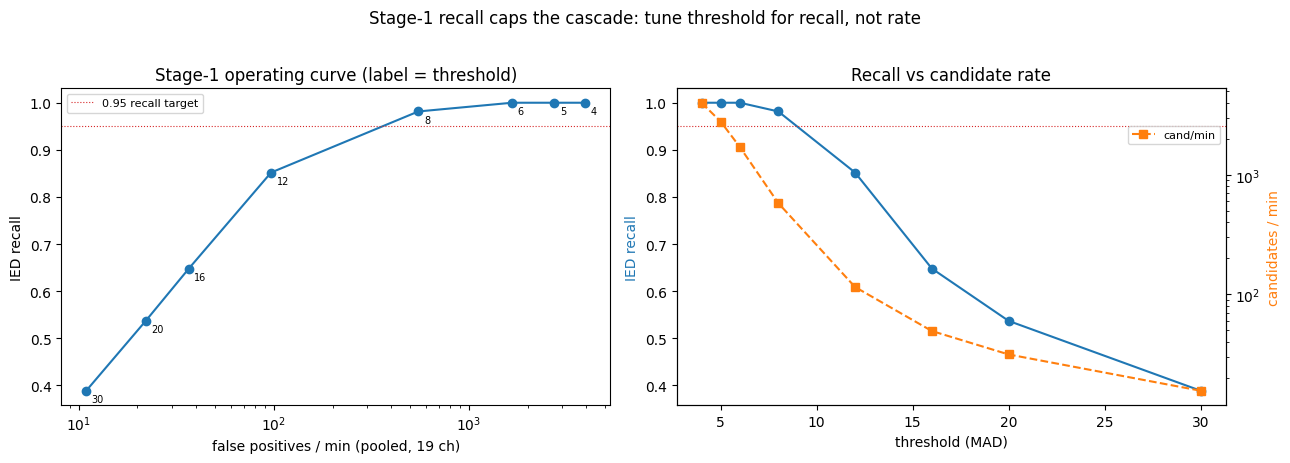

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(op.fp_per_min, op.ied_recall, 'o-', color='C0')
for _, r in op.iterrows():
    ax[0].annotate(f"{r.threshold:.0f}", (r.fp_per_min, r.ied_recall), fontsize=7,
                   textcoords='offset points', xytext=(4, -8))
ax[0].axhline(0.95, color='C3', ls=':', lw=0.8, label='0.95 recall target')
ax[0].set_xscale('log'); ax[0].set_xlabel('false positives / min (pooled, 19 ch)')
ax[0].set_ylabel('IED recall'); ax[0].set_title('Stage-1 operating curve (label = threshold)')
ax[0].legend(fontsize=8)
ax[1].plot(op.threshold, op.ied_recall, 'o-', color='C0', label='IED recall')
ax[1].set_xlabel('threshold (MAD)'); ax[1].set_ylabel('IED recall', color='C0')
ax2 = ax[1].twinx(); ax2.plot(op.threshold, op.cand_per_min, 's--', color='C1', label='cand/min')
ax2.set_ylabel('candidates / min', color='C1'); ax2.set_yscale('log')
ax[1].axhline(0.95, color='C3', ls=':', lw=0.8); ax[1].set_title('Recall vs candidate rate')
plt.suptitle('Stage-1 recall caps the cascade: tune threshold for recall, not rate', y=1.02)
plt.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1, 0.9))
plt.tight_layout()
plt.savefig('../figures/detection_stage1_operating.png', dpi=800, bbox_inches='tight')
plt.show()

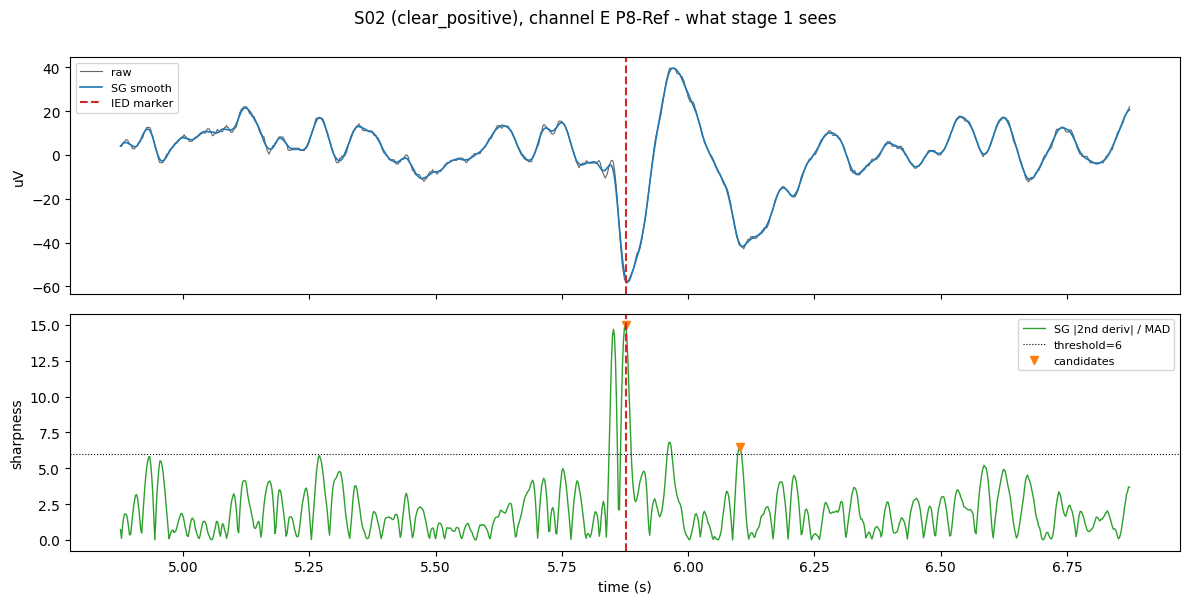

In [14]:
# eyeball one clear positive on its sharpest channel: raw, SG fit, statistic, threshold, candidates
TH_SHOW = 6
ex = next(r for r in recs if r['cert'] == 'clear_positive')
ci = int(np.argmax([STAT[recs.index(ex)][c][ex['mk']] for c in range(len(CH19))]))   # sharpest at marker
stat = STAT[recs.index(ex)]
lo, hi = ex['mk'] - int(1.0 * SF), ex['mk'] + int(1.0 * SF)
tt = np.arange(lo, hi) / SF
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(tt, ex['X'][ci][lo:hi], color='0.4', lw=0.8, label='raw')
axs[0].plot(tt, savgol_filter(ex['X'][ci], SG_WIN, SG_POLY)[lo:hi], color='C0', lw=1.2, label='SG smooth')
axs[0].axvline(ex['mk'] / SF, color='C3', ls='--', label='IED marker'); axs[0].set_ylabel('uV'); axs[0].legend(fontsize=8)
axs[1].plot(tt, stat[ci][lo:hi], color='C2', lw=1.0, label='SG |2nd deriv| / MAD')
axs[1].axhline(TH_SHOW, color='k', ls=':', lw=0.8, label=f'threshold={TH_SHOW}')
cs = [p for c, p in candidates(stat, TH_SHOW) if c == ci and lo <= p < hi]
axs[1].plot(np.array(cs) / SF, stat[ci][cs], 'v', color='C1', label='candidates')
axs[1].axvline(ex['mk'] / SF, color='C3', ls='--'); axs[1].set_xlabel('time (s)'); axs[1].set_ylabel('sharpness'); axs[1].legend(fontsize=8)
plt.suptitle(f"{ex['fid']} ({ex['cert']}), channel {CH19[ci]} - what stage 1 sees", y=1.0)
plt.tight_layout()
plt.savefig('../figures/detection_stage1_example.png', dpi=800, bbox_inches='tight')
plt.show()

In [15]:
best = op[op.ied_recall >= 0.99]
pick = (best.iloc[best.cand_per_min.argmin()] if len(best) else op.iloc[op.ied_recall.argmax()])
print(f"Highest-threshold operating point at >=99% IED recall: threshold={pick.threshold:.0f}")
print(f"  IED recall {pick.ied_recall:.2f} | {pick.cand_per_min:.0f} cand/min pooled "
      f"({pick.cand_per_min/len(CH19):.0f}/min/channel) | {pick.fp_per_min:.0f} FP/min")
print()
print("Gating verdict: SG 2nd-derivative threshold clears the recall bar. Front end is viable.")
print("Next: (1) spatial grouping to collapse per-channel candidates into events (cuts FP rate),")
print("      (2) retrain layer 2 on these candidates (positives near markers, negatives = the rest),")
print("      (3) 90/10 recording-level split + FROC (sensitivity vs FP/min), centre baseline.")
print("Threshold is characterised on all 100 here; FINALISE it on the 90-recording train split only.")

Highest-threshold operating point at >=99% IED recall: threshold=6
  IED recall 1.00 | 1703 cand/min pooled (90/min/channel) | 1664 FP/min

Gating verdict: SG 2nd-derivative threshold clears the recall bar. Front end is viable.
Next: (1) spatial grouping to collapse per-channel candidates into events (cuts FP rate),
      (2) retrain layer 2 on these candidates (positives near markers, negatives = the rest),
      (3) 90/10 recording-level split + FROC (sensitivity vs FP/min), centre baseline.
Threshold is characterised on all 100 here; FINALISE it on the 90-recording train split only.
